In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import neural_ssm
from neural_ssm import DeepSSM
from pathlib import Path
import numpy as np




In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_eigenvalues_unit_circle(eigenvalues, title="Eigenvalues on Unit Circle", label="Eigenvalues"):
    """
    Plot autovalori sul cerchio unitario.
    
    Args:
        eigenvalues: torch.Tensor di autovalori (può essere 1D o multidimensionale)
        title: titolo del plot
        label: etichetta per la legenda
    
    Returns:
        fig, ax: figure e axes di matplotlib
    """
    
    # Converti in numpy se è un tensor
    if isinstance(eigenvalues, torch.Tensor):
        eigs_numpy = eigenvalues.detach().cpu().numpy()
    else:
        eigs_numpy = np.array(eigenvalues)
    
    # Appiattisci se necessario
    eigs_numpy = eigs_numpy.flatten()
    
    # Estrai parte reale e immaginaria
    real_part = eigs_numpy.real
    imag_part = eigs_numpy.imag
    
    # Calcola il modulo
    magnitude = np.sqrt(real_part**2 + imag_part**2)
    
    # Crea il plot
    fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
    
    # Cerchio unitario
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=2, label='Unit Circle', alpha=0.5)
    
    # Plot autovalori
    ax.scatter(real_part, imag_part, s=100, c='#3b82f6', 
              alpha=0.7, edgecolors='#1e40af', linewidth=1.5, zorder=5, label=label)
    
    # Assi
    ax.axhline(y=0, color='white', linewidth=0.8, alpha=0.3)
    ax.axvline(x=0, color='white', linewidth=0.8, alpha=0.3)
    
    # Grid
    ax.grid(True, alpha=0.2, linestyle='--')
    
    # Etichette
    ax.set_xlabel('Real Part', fontsize=12, fontweight='bold')
    ax.set_ylabel('Imaginary Part', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Limiti assi
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    
    # Legend
    ax.legend(fontsize=11)
    
    # Statistiche
    stats = f"""Statistiche:
Autovalori: {len(eigs_numpy)}
Max |λ|: {np.max(magnitude):.4f}
Min |λ|: {np.min(magnitude):.4f}
Media |λ|: {np.mean(magnitude):.4f}
Stabili: {np.sum(magnitude <= 1)}/{len(eigs_numpy)}"""
    
    ax.text(-1.15, -0.5, stats, fontsize=10, family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    return fig, ax


Matrice A di SSM_0, pasti
Block 0 - A shape: torch.Size([16, 16]), max|eigenvalue|: 0.9836, min|eigenvalue|: 0.0622
Block 1 - A shape: torch.Size([16, 16]), max|eigenvalue|: 0.9835, min|eigenvalue|: 0.0170
Block 2 - A shape: torch.Size([16, 16]), max|eigenvalue|: 0.9250, min|eigenvalue|: 0.0976
Block 3 - A shape: torch.Size([16, 16]), max|eigenvalue|: 0.7962, min|eigenvalue|: 0.0184
Block 4 - A shape: torch.Size([16, 16]), max|eigenvalue|: 0.9070, min|eigenvalue|: 0.0220
Block 5 - A shape: torch.Size([16, 16]), max|eigenvalue|: 0.9074, min|eigenvalue|: 0.0264
Block 6 - A shape: torch.Size([16, 16]), max|eigenvalue|: 0.9045, min|eigenvalue|: 0.0329


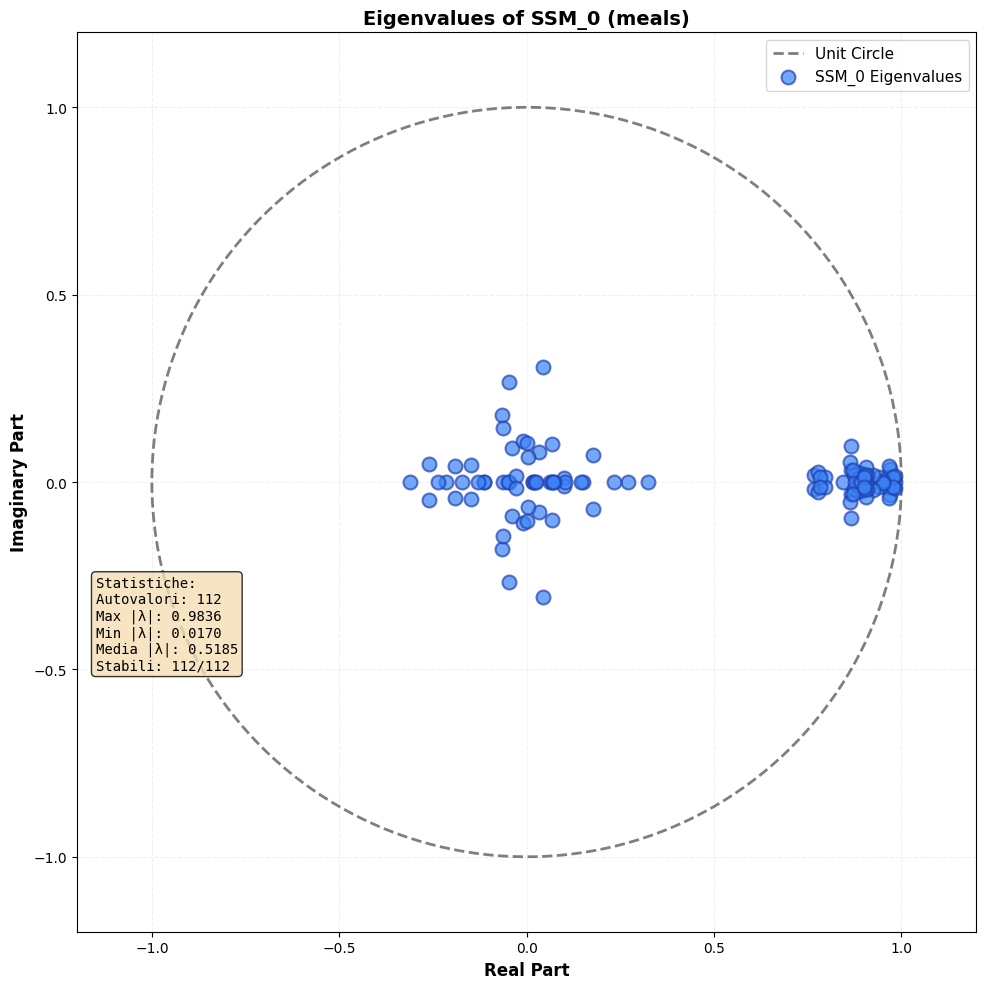

tensor([-2.6042e-01+0.0469j, -2.6042e-01-0.0469j, -6.4911e-02+0.1778j,
        -6.4911e-02-0.1778j, -6.3492e-02+0.0000j,  6.2184e-02+0.0000j,
         1.0004e-01+0.0111j,  1.0004e-01-0.0111j,  9.6928e-01+0.0342j,
         9.6928e-01-0.0342j,  9.8360e-01+0.0000j,  9.3985e-01+0.0138j,
         9.3985e-01-0.0138j,  9.6503e-01+0.0124j,  9.6503e-01-0.0124j,
         9.6180e-01+0.0000j, -3.1049e-01+0.0000j, -4.7732e-02+0.2676j,
        -4.7732e-02-0.2676j, -6.2223e-02+0.1440j, -6.2223e-02-0.1440j,
        -1.1350e-01+0.0000j,  1.0243e-01+0.0000j,  1.6965e-02+0.0000j,
         9.6744e-01+0.0432j,  9.6744e-01-0.0432j,  9.8338e-01+0.0160j,
         9.8338e-01-0.0160j,  9.7780e-01+0.0135j,  9.7780e-01-0.0135j,
         9.5178e-01+0.0020j,  9.5178e-01-0.0020j, -1.4709e-01+0.0456j,
        -1.4709e-01-0.0456j, -3.8238e-02+0.0898j, -3.8238e-02-0.0898j,
         6.7956e-02+0.1012j,  6.7956e-02-0.1012j,  1.5155e-01+0.0000j,
         3.2515e-01+0.0000j,  8.4345e-01+0.0000j,  9.2475e-01+0.0201j,
      

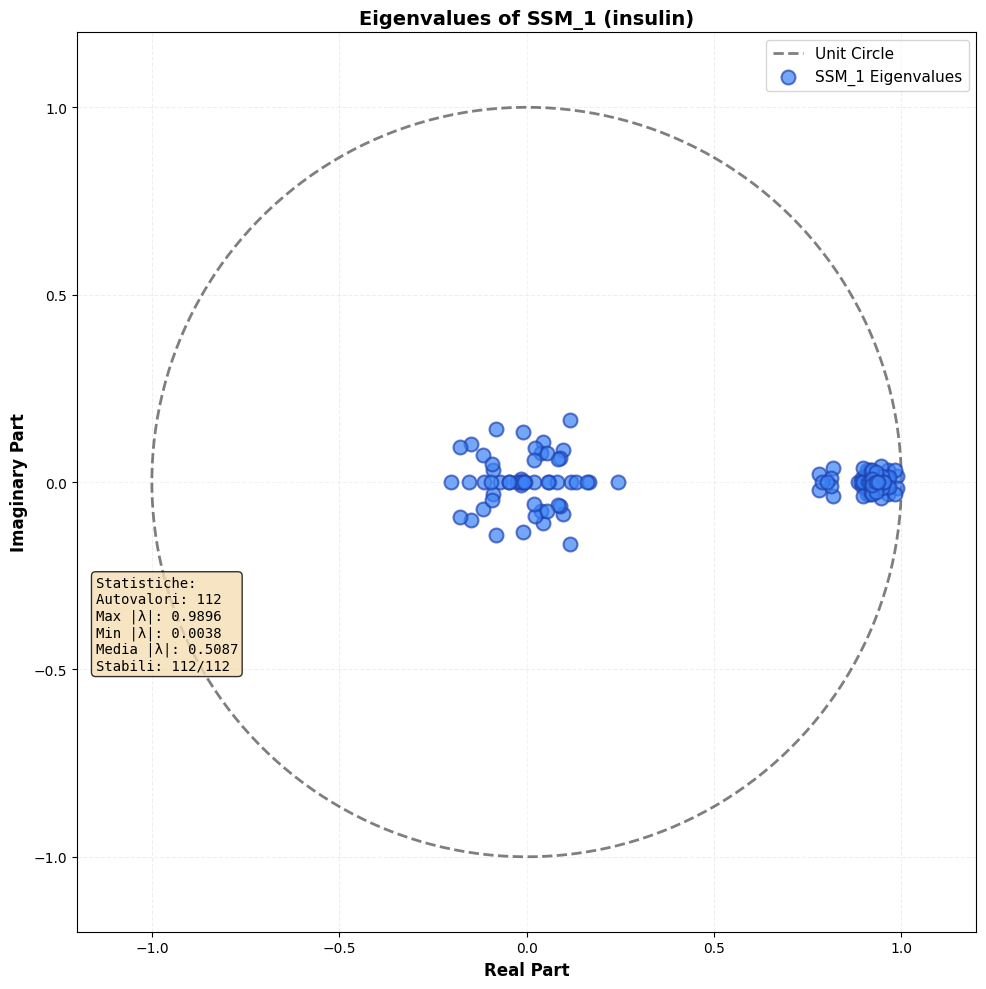

tensor([-0.1478+0.1011j, -0.1478-0.1011j,  0.0959+0.0855j,  0.0959-0.0855j,
         0.1173+0.0000j, -0.0711+0.0000j, -0.0138+0.0000j,  0.0187+0.0000j,
         0.9080+0.0320j,  0.9080-0.0320j,  0.8854+0.0000j,  0.9017+0.0155j,
         0.9017-0.0155j,  0.9008+0.0000j,  0.8960+0.0096j,  0.8960-0.0096j,
        -0.1766+0.0945j, -0.1766-0.0945j,  0.0428+0.1081j,  0.0428-0.1081j,
        -0.0152+0.0087j, -0.0152-0.0087j,  0.0904+0.0650j,  0.0904-0.0650j,
         0.9895+0.0155j,  0.9895-0.0155j,  0.9645+0.0312j,  0.9645-0.0312j,
         0.9822+0.0308j,  0.9822-0.0308j,  0.9611+0.0101j,  0.9611-0.0101j,
         0.2445+0.0000j, -0.0886+0.0316j, -0.0886-0.0316j, -0.0247+0.0000j,
         0.0385+0.0777j,  0.0385-0.0777j,  0.1317+0.0000j,  0.0592+0.0000j,
         0.9462+0.0415j,  0.9462-0.0415j,  0.9663+0.0141j,  0.9663-0.0141j,
         0.9327+0.0000j,  0.9474+0.0161j,  0.9474-0.0161j,  0.9502+0.0000j,
        -0.0805+0.1409j, -0.0805-0.1409j, -0.1137+0.0000j, -0.0939+0.0000j,
        -0.0

In [23]:
patient_model_folder_101_M = f".\models\SSM\exp_5_30days_rwgn\paz_010\strategy_1"
MODEL_PATH = Path(patient_model_folder_101_M)

SSM_0 = DeepSSM(d_input=1, d_output=1, d_model = 8, ff='GLU', param='l2n',
                    d_state=8, n_layers=7, max_phase_b=0.04,  d_hidden=12, dim_amp=3)  

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_0.eval()


SSM_1 = DeepSSM(d_input=1, d_output=1, d_model = 8, ff='GLU', param='l2n',
                    d_state=8, n_layers=7, max_phase_b=0.04,  d_hidden=12, dim_amp=3)  

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])
SSM_1.eval()


print('Matrice A di SSM_0, pasti')

A_matrices = []
total_meal_eig_list = []
for i, block in enumerate(SSM_0.blocks):
    K11, K12, K21, K22 = block.lru._build_K_blocks()
    A = torch.cat([
        torch.cat([K11, K12], dim=1),
        torch.cat([K21, K22], dim=1)
    ], dim=0)
    A_matrices.append(A)
    
    eigenvalues = torch.linalg.eigvals(A)
    total_meal_eig_list.append(eigenvalues)
    max_eig = torch.max(torch.abs(eigenvalues))
    min_eig = torch.min(torch.abs(eigenvalues))
    print(f"Block {i} - A shape: {A.shape}, max|eigenvalue|: {max_eig:.4f}, min|eigenvalue|: {min_eig:.4f}")

total_meal_eig = torch.cat([t.flatten() for t in total_meal_eig_list])

plot_eigenvalues_unit_circle(total_meal_eig, title="Eigenvalues of SSM_0 (meals)", label="SSM_0 Eigenvalues")
plt.show()

print(total_meal_eig)
# Salva tutte le matrici
print(f"\nTotale matrici A: {len(A_matrices)}")

##############################################################################################################################################

print('\nMatrice A di SSM_0, insulina')

A_matrices = []
C_matrices = []
D_matrices = []
total_insuline_eig_list = []
for i, block in enumerate(SSM_1.blocks):
    K11, K12, K21, K22 = block.lru._build_K_blocks()
    A = torch.cat([
        torch.cat([K11, K12], dim=1),
        torch.cat([K21, K22], dim=1)
    ], dim=0)
    A_matrices.append(A)
    
    eigenvalues = torch.linalg.eigvals(A)
    total_insuline_eig_list.append(eigenvalues)
    max_eig = torch.max(torch.abs(eigenvalues))
    min_eig = torch.min(torch.abs(eigenvalues))
    print(f"Block {i} - A shape: {A.shape}, max|eigenvalue|: {max_eig:.4f}, min|eigenvalue|: {min_eig:.4f}")
    
    lru = block.lru
    # ===== Matrice C =====
    # C è la matrice di uscita (output projection)
    if hasattr(lru, 'C'):
        C_complex = lru.C  # (d_output, d_state)
        # Converti da complesso a reale (prendi la parte reale per ora)
        C_real = C_complex.real
    else:
        # Se non esiste, usa una matrice identità
        C_real = torch.eye(A.shape[0])
    C_matrices.append(C_real)
    
    # ===== Matrice D =====
    # D è la matrice di feedthrough (direct path input->output)
    if hasattr(lru, 'D'):
        D = lru.D  # (d_output, d_input)
        D_real = D
    else:
        # Se non esiste, usa zero
        D_real = torch.zeros(1, A.shape[0])
    D_matrices.append(D_real)
    print(f"Block {i}: A{A.shape}, C{C_real.shape}, D{D_real.shape}")
    
    
total_insuline_eig = torch.cat([t.flatten() for t in total_insuline_eig_list])

plot_eigenvalues_unit_circle(total_insuline_eig, title="Eigenvalues of SSM_1 (insulin)", label="SSM_1 Eigenvalues")
plt.show()

print(total_insuline_eig)